Support Vector Machines (SVMs) are a type of machine learning algorithm used for classification and regression analysis. In particular, linear SVMs are used for binary classification problems where the goal is to separate two classes by a hyperplane.

The hyperplane is a line that divides the feature space into two regions. The SVM algorithm tries to find the hyperplane that maximizes the margin, which is the distance between the hyperplane and the closest points from each class. The points closest to the hyperplane are called support vectors and play a crucial role in the algorithm's optimization process.

In linear SVMs, the hyperplane is defined by a linear function of the input features. The algorithm tries to find the optimal values of the coefficients of this function, called weights, that maximize the margin. This optimization problem can be formulated as a quadratic programming problem, which can be efficiently solved using standard optimization techniques.

In addition to finding the optimal hyperplane, SVMs can also handle non-linearly separable data by using a kernel trick. This technique maps the input features into a higher-dimensional space, where they might become linearly separable. The SVM algorithm then finds the optimal hyperplane in this transformed feature space, which corresponds to a non-linear decision boundary in the original feature space.

Linear SVMs have been widely used in many applications, including text classification, image classification, and bioinformatics. They have the advantage of being computationally efficient and easy to interpret. However, they may not perform well in highly non-linearly separable datasets, where non-linear SVMs may be a better choice.

Key terms: support vector, margin, C, hyperplane, kernel tricks, hinge loss

In [125]:
import numpy as np

class SVM:
    def __init__(self, lr=0.001, C=100, n_iters=1000):
        # note C is usually known as 1/(2*lambda_param)
        self.lr = lr
        self.C = C
        self.lambda_param = 1 / (2 * self.C)
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            # first we calculate the margins -> which is the derivation of hinge loss np.max(0, 1 - y(Xw + b) over w
            margins = y_ * (np.dot(X, self.w) + self.b) # since this is margin, get the margin < 1
            # then we get the mask where margin is too small
            mask = margins < 1

            # prepare the regularization term
            dw_reg = 2 * self.lambda_param * self.w

            if np.any(mask):
                dw = -np.dot(X[mask].T, y_[mask]) / n_samples
                db = -np.sum(y_[mask])/n_samples
            else:
                dw,db = 0,0
            
            self.w -= self.lr * (dw + dw_reg)
            self.b -= self.lr * db


    def predict(self, X):
        linear_out = np.dot(X,self.w) + self.b
        return np.sign(linear_out)

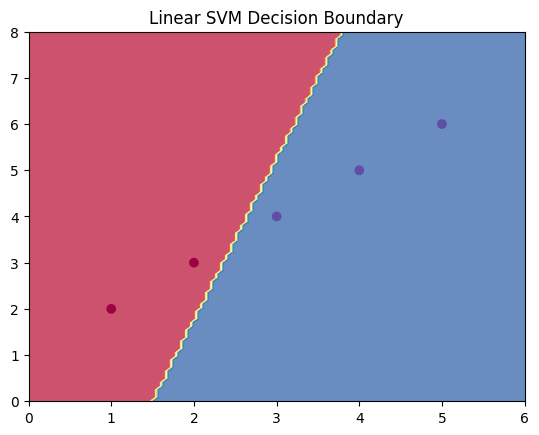

In [126]:
import matplotlib.pyplot as plt

# create sample dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([-1, -1, 1, 1, 1])  # for SVM, label should be -1 and 1

# initialize SVM model
svm = SVM(lr=0.01, C=500, n_iters=10000)
# svm = SVM(learning_rate = 0.01, lambda_param=0.01, n_iters=1000)
svm.fit(X, y)

# plot decision boundary
x1 = np.linspace(0, 6, 100)
x2 = np.linspace(0, 8, 100)
xx, yy = np.meshgrid(x1, x2)
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# plot data points
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)
plt.title("Linear SVM Decision Boundary")
plt.show()
